# 02 · Análise exploratória e insights de negócio

Cada análise começa com a **pergunta de negócio** e termina com o **"e daí"**. A ordem segue o enunciado: preço médio, dia da semana e comportamento ao longo do dia, seguidos de três insights extras.

**Hipóteses que vamos testar**
- H1. Novembro (Black November) vende mais porque o desconto compra volume, não porque a demanda orgânica cresce.
- H2. Datas de presente (Dia das Mães, Namorados) se comportam diferente: demanda orgânica, com preço médio mais alto.
- H3. Existe um dia da semana claramente mais forte, mesmo descontando os eventos.
- H4. O App concentra a compra noturna; o Site, o horário comercial.

In [1]:
import sys; sys.path.append("..")
import pandas as pd, numpy as np, matplotlib.pyplot as plt, matplotlib.ticker as mt, seaborn as sns
from src.data import diario, grid_completo, EVENTOS, NAO_ID, METRICAS
from src.viz import aplicar_estilo, salvar, reais_mi, VERDE, VERDE_CLARO, CORAL, CINZA, CINZA_ESC
aplicar_estilo(); pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
df = pd.read_pickle("../data/vendas_tratadas.pkl")
df["data"] = df.dt_hr_venda.dt.normalize(); df["hora"] = df.dt_hr_venda.dt.hour
d = diario(df)
ev = {k: pd.Timestamp(v) for k, v in EVENTOS.items()}
DIAS = ["Seg", "Ter", "Qua", "Qui", "Sex", "Sáb", "Dom"]

## 0. Visão geral: como a receita se move no período

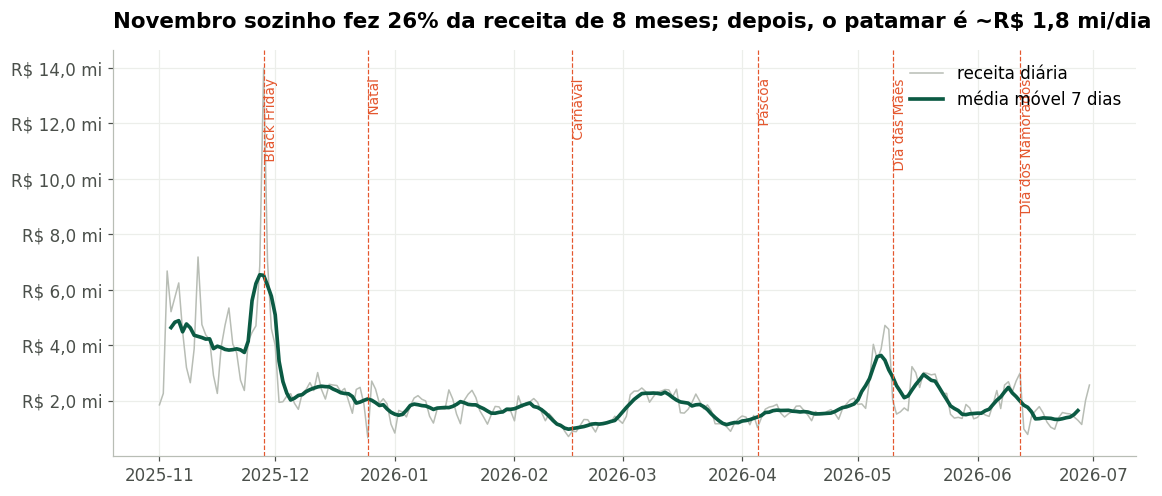

In [2]:
fig, ax = plt.subplots(figsize=(12, 4.8))
ax.plot(d.index, d.receita_aprovada, color=CINZA, lw=1, label="receita diária")
ax.plot(d.index, d.receita_aprovada.rolling(7, center=True).mean(), color=VERDE, lw=2.4, label="média móvel 7 dias")
for nome in ["Black Friday", "Natal", "Carnaval", "Páscoa", "Dia das Mães", "Dia dos Namorados"]:
    x = ev[nome]; ax.axvline(x, color=CORAL, lw=0.8, ls="--")
    ax.text(x, ax.get_ylim()[1]*0.93, f" {nome}", color=CORAL, fontsize=9, rotation=90, va="top")
ax.yaxis.set_major_formatter(mt.FuncFormatter(reais_mi))
ax.set_title("Novembro sozinho fez 26% da receita de 8 meses; depois, o patamar é ~R$ 1,8 mi/dia")
ax.legend(loc="upper right"); salvar(fig, "02_serie_diaria"); plt.show()

In [3]:
m = d.resample("MS")[["receita_aprovada"]].sum()
m["% do período"] = m.receita_aprovada / m.receita_aprovada.sum()
m["receita (R$ mi)"] = m.receita_aprovada / 1e6
m.index = m.index.strftime("%b/%y"); m[["receita (R$ mi)", "% do período"]]

,receita (R$ mi),% do período
data,,
Nov/25,140.66,0.26
Dec/25,68.78,0.13
Jan/26,53.53,0.10
Feb/26,38.01,0.07
Mar/26,56.70,0.11
Apr/26,47.78,0.09
May/26,75.78,0.14
Jun/26,51.16,0.10


**E daí:** a série tem dois regimes. Novembro é um mês de campanha com receita diária média 2,5x maior que o resto. Qualquer média simples do período fica distorcida por ele, e o modelo precisa saber disso (notebook 03).

## 1. Preço médio de venda

**Pergunta de negócio:** o cliente compra mais caro ou mais barato ao longo do tempo, e o desconto está comprando volume?

Definições (sempre soma / soma): preço médio por item = receita / itens; ticket médio = receita / pedidos; % desconto = desconto / (receita + desconto).

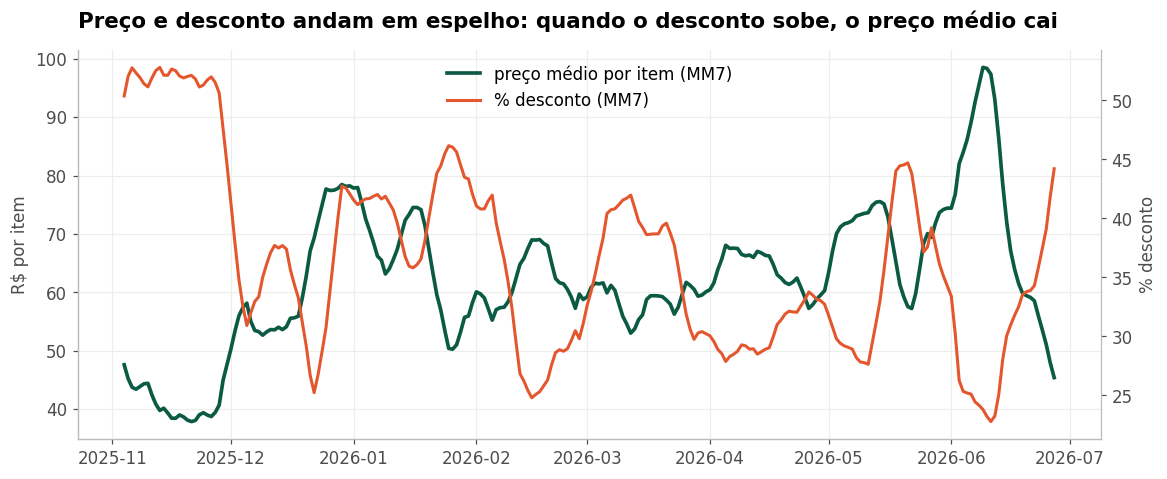

In [4]:
fig, ax1 = plt.subplots(figsize=(12, 4.6))
ax1.plot(d.index, d.preco_medio_item.rolling(7, center=True).mean(), color=VERDE, lw=2.4, label="preço médio por item (MM7)")
ax1.set_ylabel("R$ por item"); ax2 = ax1.twinx()
ax2.plot(d.index, (d.pct_desconto*100).rolling(7, center=True).mean(), color=CORAL, lw=2, label="% desconto (MM7)")
ax2.set_ylabel("% desconto"); ax2.grid(False); ax2.spines["right"].set_visible(True)
ax1.set_title("Preço e desconto andam em espelho: quando o desconto sobe, o preço médio cai")
h1, l1 = ax1.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels(); ax1.legend(h1+h2, l1+l2, loc="upper center")
salvar(fig, "02_preco_desconto"); plt.show()

### Decomposição: de onde vem a receita de novembro?

`receita = pedidos × itens por pedido × preço por item`. Comparar os três fatores entre novembro e o resto mostra o que de fato mudou.

In [5]:
def resumo(s):
    return pd.Series({"receita/dia (R$ mi)": s.receita_aprovada.sum()/len(s)/1e6,
                      "pedidos/dia": s.nr_pedidos.sum()/len(s),
                      "itens por pedido": s.qt_material.sum()/s.nr_pedidos.sum(),
                      "preço por item (R$)": s.receita_aprovada.sum()/s.qt_material.sum(),
                      "% desconto": s.vlr_venda_desconto.sum()/(s.vlr_venda_desconto.sum()+s.receita_aprovada.sum())*100})
dec = pd.DataFrame({"Novembro": resumo(d.loc[:"2025-11-30"]), "Dez a Jun": resumo(d.loc["2025-12-01":]) })
dec["variação nov vs resto"] = dec.Novembro / dec["Dez a Jun"] - 1
dec

,Novembro,Dez a Jun,variação nov vs resto
receita/dia (R$ mi),4.69,1.85,1.54
pedidos/dia,"73,171.40","20,404.50",2.59
itens por pedido,1.64,1.46,0.12
preço por item (R$),39.14,62.16,-0.37
% desconto,52.80,36.21,0.46


**E daí:** em novembro, os pedidos diários são 3,6x maiores, mas o preço por item é 37% menor e o desconto vai de 36% para 53%. **H1 confirmada: a receita de novembro é volume comprado com desconto.** Isso não é ruim por si só, mas significa que crescimento de receita em campanha não é sinal de demanda orgânica, e que a margem precisa entrar na conta.

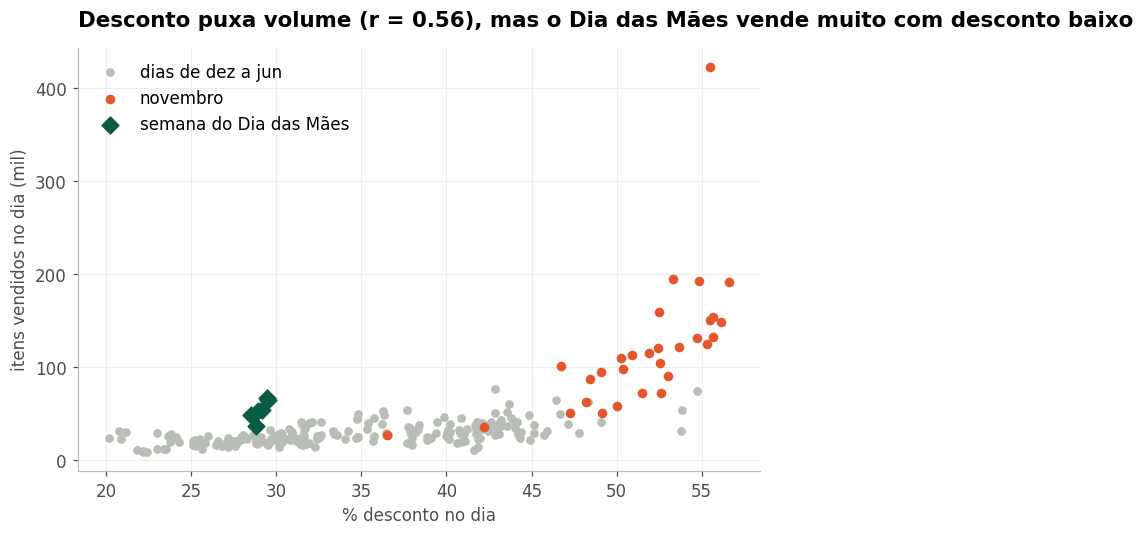

In [6]:
x = d.loc["2025-12-01":]
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(x.pct_desconto*100, x.qt_material/1e3, color=CINZA, s=22, label="dias de dez a jun")
nov = d.loc[:"2025-11-30"]; ax.scatter(nov.pct_desconto*100, nov.qt_material/1e3, color=CORAL, s=28, label="novembro")
maes = d.loc["2026-05-04":"2026-05-09"]; ax.scatter(maes.pct_desconto*100, maes.qt_material/1e3, color=VERDE, s=60, marker="D", label="semana do Dia das Mães")
ax.set_xlabel("% desconto no dia"); ax.set_ylabel("itens vendidos no dia (mil)")
r = np.corrcoef(x.pct_desconto, np.log(x.qt_material))[0, 1]
ax.set_title(f"Desconto puxa volume (r = {r:.2f}), mas o Dia das Mães vende muito com desconto baixo")
ax.legend(loc="upper left"); salvar(fig, "02_desconto_volume"); plt.show()

In [7]:
comp = pd.DataFrame({
    "Black Friday (28/11)": d.loc["2025-11-28"],
    "Pico Dia das Mães (08/05)": d.loc["2026-05-08"],
    "Dia típico (mediana dez-jun)": d.loc["2025-12-01":].median()})
comp.loc[["receita_aprovada", "qt_material", "preco_medio_item", "ticket_medio", "pct_desconto"]]

,Black Friday (28/11),Pico Dia das Mães (08/05),Dia típico (mediana dez-jun)
receita_aprovada,"13,989,625.10","4,719,693.75","1,718,796.36"
qt_material,"422,860.00","67,063.00","27,119.00"
preco_medio_item,33.08,70.38,63.00
ticket_medio,55.52,93.17,91.65
pct_desconto,0.55,0.29,0.33


**E daí (H2 confirmada):** na Black Friday o preço por item foi R$ 33 com 55% de desconto. No pico do Dia das Mães, R$ 70 com 29%, acima do preço de um dia típico. **Black Friday é demanda comprada; Dia das Mães é demanda orgânica.** Implicação: no Dia das Mães, desconto agressivo tende a só transferir margem para quem já ia comprar.

### Preço por categoria e canal

In [8]:
k = df[df.categoria != NAO_ID]
cat = k.groupby("categoria")[METRICAS].sum()
cat["% receita"] = cat.receita_aprovada / cat.receita_aprovada.sum()*100
cat["preço/item"] = cat.receita_aprovada / cat.qt_material
cat["% desconto"] = cat.vlr_venda_desconto / (cat.receita_aprovada + cat.vlr_venda_desconto)*100
cat = cat.sort_values("% receita", ascending=False)[["% receita", "preço/item", "% desconto"]]
canal = df.groupby("canal")[METRICAS].sum()
canal["% receita"] = canal.receita_aprovada/canal.receita_aprovada.sum()*100
canal["preço/item"] = canal.receita_aprovada/canal.qt_material
canal["ticket"] = canal.receita_aprovada/canal.nr_pedidos
canal["% desconto"] = canal.vlr_venda_desconto/(canal.receita_aprovada+canal.vlr_venda_desconto)*100
display(cat); canal[["% receita", "preço/item", "ticket", "% desconto"]]

,% receita,preço/item,% desconto
categoria,,,
PERFUMARIA MASCULINA,27.31,81.08,41.19
PERFUMARIA FEMININA,26.14,61.29,48.26
CORPO E BANHO,15.51,36.61,40.38
PERF. DE ENTRADA E DEOS,11.00,45.75,27.17
GIFTS,10.79,112.75,30.17
MAQUIAGEM,3.78,32.19,42.51
CABELOS,3.61,27.58,41.25
FACIAL,1.86,21.30,62.85


,% receita,preço/item,ticket,% desconto
canal,,,,
App,76.23,52.52,79.77,42.75
Site,23.77,58.35,88.32,37.73


**E daí:** perfumaria (feminina + masculina) é 53% da receita. O App responde por 76% da receita, com ticket 10% menor e desconto 5 p.p. maior que o Site: o App é o canal de volume e promoção; o Site, de compra mais cara e menos sensível a preço. Facial tem o maior desconto (63%) com só 2% da receita: vale revisar a política de desconto dessa categoria.

## 2. Potencial de vendas por dia da semana

**Pergunta de negócio:** onde concentrar campanha, mídia e estoque na semana?

Cuidado metodológico: a Black Friday cai numa sexta e novembro inteiro é atípico. Por isso, calculamos o índice **de dezembro a junho, sem os dias de evento**, e mostramos também a versão ingênua para comparar.

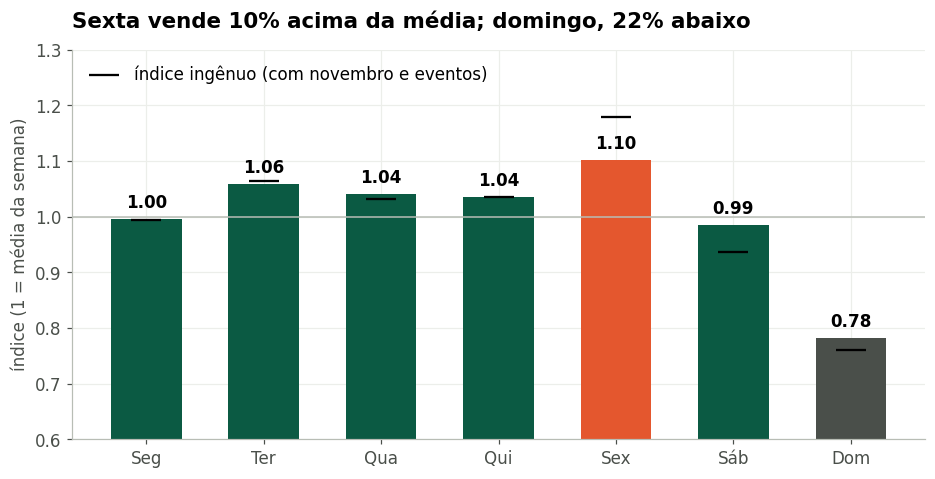

In [9]:
base = d.loc["2025-12-01":]; base = base[~base.index.isin(list(ev.values()))]
ind_limpo = base.groupby(base.index.dayofweek).receita_aprovada.mean(); ind_limpo /= ind_limpo.mean()
ind_ing = d.groupby(d.index.dayofweek).receita_aprovada.mean(); ind_ing /= ind_ing.mean()
fig, ax = plt.subplots(figsize=(10, 4.6))
cores = [CORAL if v == ind_limpo.max() else (CINZA_ESC if v == ind_limpo.min() else VERDE) for v in ind_limpo]
ax.bar(DIAS, ind_limpo.values, color=cores, width=0.6)
ax.scatter(DIAS, ind_ing.values, color="black", marker="_", s=400, zorder=3, label="índice ingênuo (com novembro e eventos)")
for i, v in enumerate(ind_limpo.values): ax.text(i, v+0.02, f"{v:.2f}", ha="center", fontweight="bold")
ax.axhline(1, color=CINZA, lw=1); ax.set_ylim(0.6, 1.3)
ax.set_title("Sexta vende 10% acima da média; domingo, 22% abaixo")
ax.set_ylabel("índice (1 = média da semana)"); ax.legend(loc="upper left")
salvar(fig, "02_dia_semana"); plt.show()

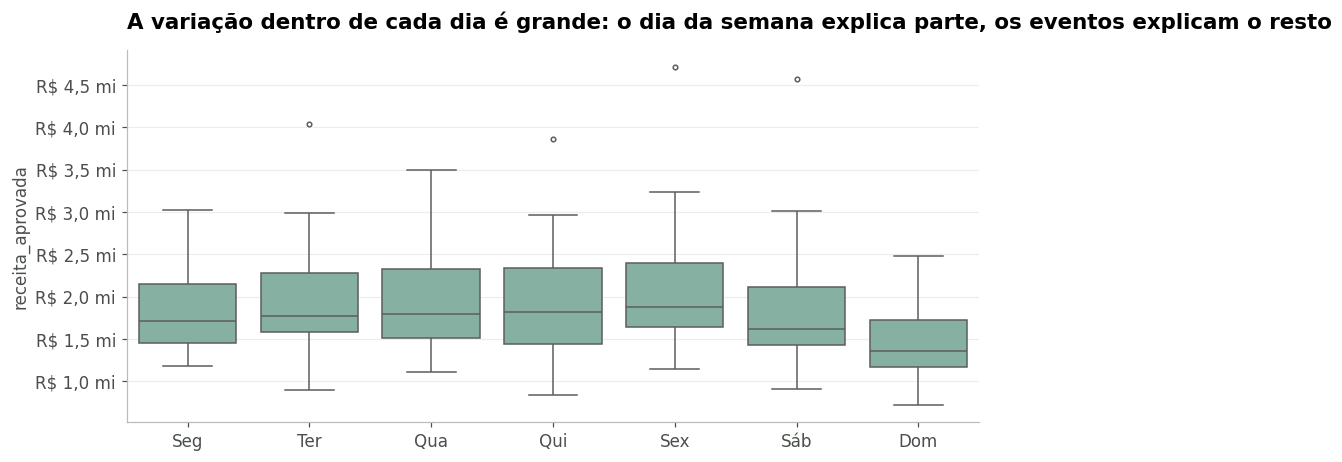

In [10]:
fig, ax = plt.subplots(figsize=(10, 4.4))
b = base.assign(dia=pd.Categorical([DIAS[i] for i in base.index.dayofweek], DIAS, ordered=True))
sns.boxplot(data=b, x="dia", y="receita_aprovada", color=VERDE_CLARO, ax=ax, fliersize=3)
ax.yaxis.set_major_formatter(mt.FuncFormatter(reais_mi)); ax.set_xlabel("")
ax.set_title("A variação dentro de cada dia é grande: o dia da semana explica parte, os eventos explicam o resto")
salvar(fig, "02_dia_semana_box"); plt.show()

In [11]:
dc = df[df.data >= "2025-12-01"].groupby([df.data.dt.dayofweek, "canal"]).receita_aprovada.sum().unstack()
(dc / dc.mean()).rename(index=dict(enumerate(DIAS))).T

data,Seg,Ter,Qua,Qui,Sex,Sáb,Dom
canal,,,,,,,
App,1.02,1.07,1.00,0.99,1.10,1.01,0.81
Site,1.09,1.10,1.06,1.04,1.12,0.86,0.73


**E daí (H3 confirmada):** a semana tem pico na sexta e vale no domingo, nos dois canais. O sábado esconde uma diferença: no App ele é um dia normal (índice 1,01), no Site cai 14%. Fim de semana é dia de App. Na média, um dia de fim de semana vende 16% menos que um dia útil. Recomendação: campanhas e disparos começando na quinta para capturar a sexta; domingo é o dia mais barato para testes de criativo, porque o custo de oportunidade é menor. Note que o índice ingênuo infla a sexta para 1,18 por causa da Black Friday: sem o cuidado, superestimaríamos o efeito da sexta.

## 3. Flutuações ao longo do dia

**Pergunta de negócio:** quando o cliente compra, e isso muda por canal e por dia?

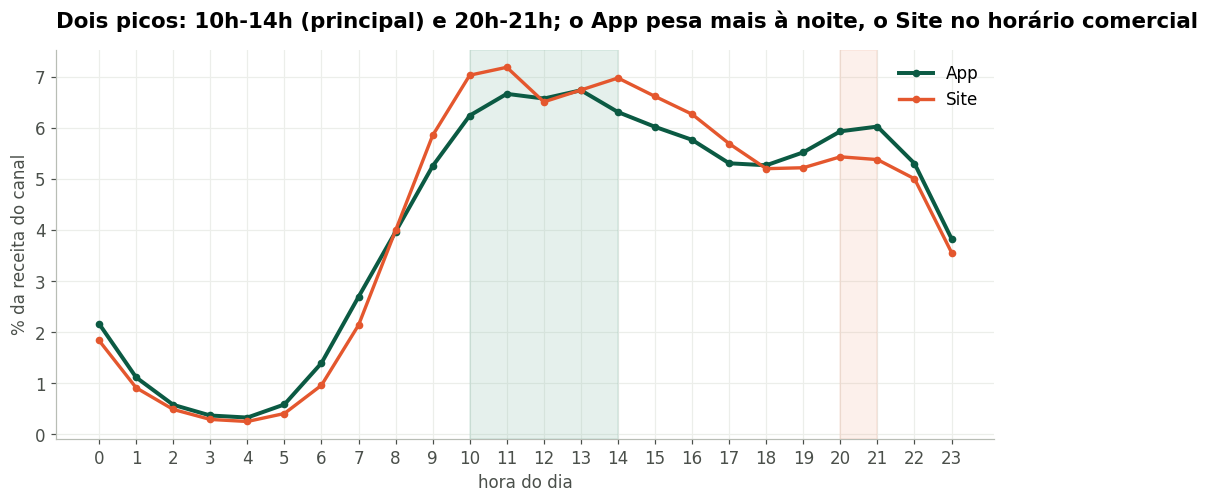

In [12]:
g = grid_completo(df)
g["hora"] = g.dt_hr_venda.dt.hour; g["dow"] = g.dt_hr_venda.dt.dayofweek
h = g.groupby(["hora", "canal"]).receita_aprovada.sum().unstack(); hs = h / h.sum() * 100
fig, ax = plt.subplots(figsize=(11, 4.6))
ax.plot(hs.index, hs.App, color=VERDE, lw=2.6, marker="o", ms=4, label="App")
ax.plot(hs.index, hs.Site, color=CORAL, lw=2.2, marker="o", ms=4, label="Site")
ax.axvspan(10, 14, color=VERDE_CLARO, alpha=0.2); ax.axvspan(20, 21, color="#F19C79", alpha=0.15)
ax.set_xticks(range(0, 24)); ax.set_xlabel("hora do dia"); ax.set_ylabel("% da receita do canal")
ax.set_title("Dois picos: 10h-14h (principal) e 20h-21h; o App pesa mais à noite, o Site no horário comercial")
ax.legend(); salvar(fig, "02_curva_horaria"); plt.show()

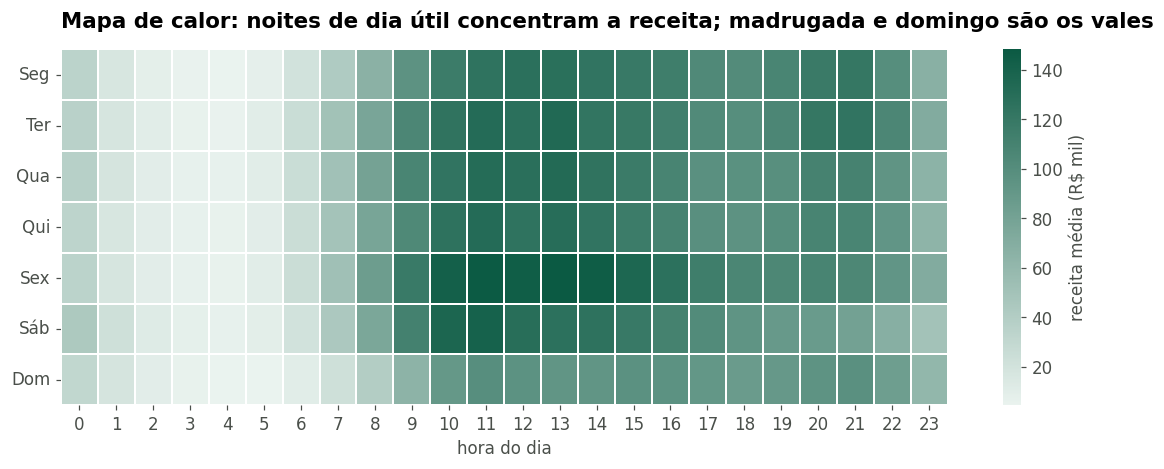

In [13]:
hm = g[g.dt_hr_venda >= "2025-12-01"].groupby(["dow", "hora"]).receita_aprovada.mean().unstack() * 0
hm = (g[g.dt_hr_venda >= "2025-12-01"].groupby([g.dt_hr_venda.dt.normalize(), "dow", "hora"]).receita_aprovada.sum()
        .groupby(["dow", "hora"]).mean().unstack())
fig, ax = plt.subplots(figsize=(13, 4.2))
sns.heatmap(hm/1e3, cmap=sns.light_palette(VERDE, as_cmap=True), ax=ax, cbar_kws={"label": "receita média (R$ mil)"}, linewidths=0.3)
ax.set_yticklabels(DIAS, rotation=0); ax.set_xlabel("hora do dia"); ax.set_ylabel("")
ax.set_title("Mapa de calor: noites de dia útil concentram a receita; madrugada e domingo são os vales")
salvar(fig, "02_heatmap_dia_hora"); plt.show()

In [14]:
acum = hs.cumsum()
print(f"Até 12h: {acum.loc[11,'App']:.0f}% da receita do dia já aconteceu (App) e {acum.loc[11,'Site']:.0f}% (Site)")
print(f"Até 18h: {acum.loc[17,'App']:.0f}% (App) e {acum.loc[17,'Site']:.0f}% (Site)")
print(f"Entre 10h e 14h: {hs.loc[10:14,'App'].sum():.0f}% (App) e {hs.loc[10:14,'Site'].sum():.0f}% (Site)")
print(f"Entre 19h e 22h: {hs.loc[19:22,'App'].sum():.0f}% (App) e {hs.loc[19:22,'Site'].sum():.0f}% (Site)")

Até 12h: 31% da receita do dia já aconteceu (App) e 31% (Site)
Até 18h: 68% (App) e 70% (Site)
Entre 10h e 14h: 33% (App) e 34% (Site)
Entre 19h e 22h: 23% (App) e 21% (Site)


/tmp/ipykernel_584/2586404958.py:3: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  tip = dia_h.loc["2025-12-01":].div(dia_h.loc["2025-12-01":].sum(1), axis=0).median()*100


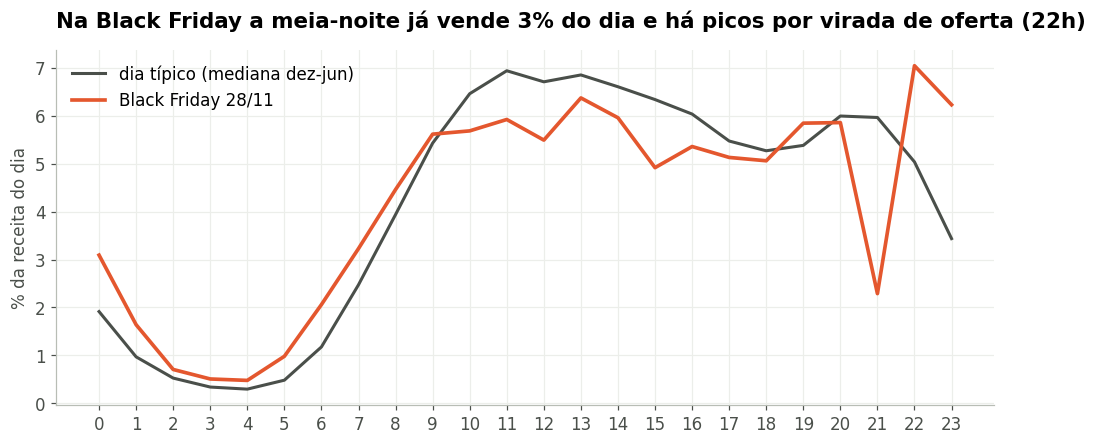

In [15]:
dia_h = g.groupby([g.dt_hr_venda.dt.normalize(), "hora"]).receita_aprovada.sum().unstack()
bf = dia_h.loc["2025-11-28"]/dia_h.loc["2025-11-28"].sum()*100
tip = dia_h.loc["2025-12-01":].div(dia_h.loc["2025-12-01":].sum(1), axis=0).median()*100
fig, ax = plt.subplots(figsize=(11, 4.2))
ax.plot(tip.index, tip, color=CINZA_ESC, lw=2, label="dia típico (mediana dez-jun)")
ax.plot(bf.index, bf, color=CORAL, lw=2.4, label="Black Friday 28/11")
ax.set_xticks(range(24)); ax.set_ylabel("% da receita do dia"); ax.legend()
ax.set_title("Na Black Friday a meia-noite já vende 3% do dia e há picos por virada de oferta (22h)")
salvar(fig, "02_bf_vs_tipico"); plt.show()

**E daí (H4 parcialmente confirmada):** os dois canais têm o mesmo formato de curva, com dois picos: o principal entre **10h e 14h (cerca de 1/3 da receita do dia em 5 horas)** e um segundo entre 20h e 21h. A diferença é de intensidade: o Site concentra mais no horário comercial e o App mais à noite. Ao meio-dia, só 31% do dia aconteceu: isso permite **estimar o fechamento do dia ao meio-dia** e corrigir mídia no mesmo dia. Recomendações: comunicação por e-mail e Site de manhã; push do App no começo da noite (19h30), antes do segundo pico. Em dias de campanha a curva muda (picos na virada de oferta), então a régua do dia típico não vale para eles.

## 4. Insights extras

### 4.1 O mix muda conforme a ocasião

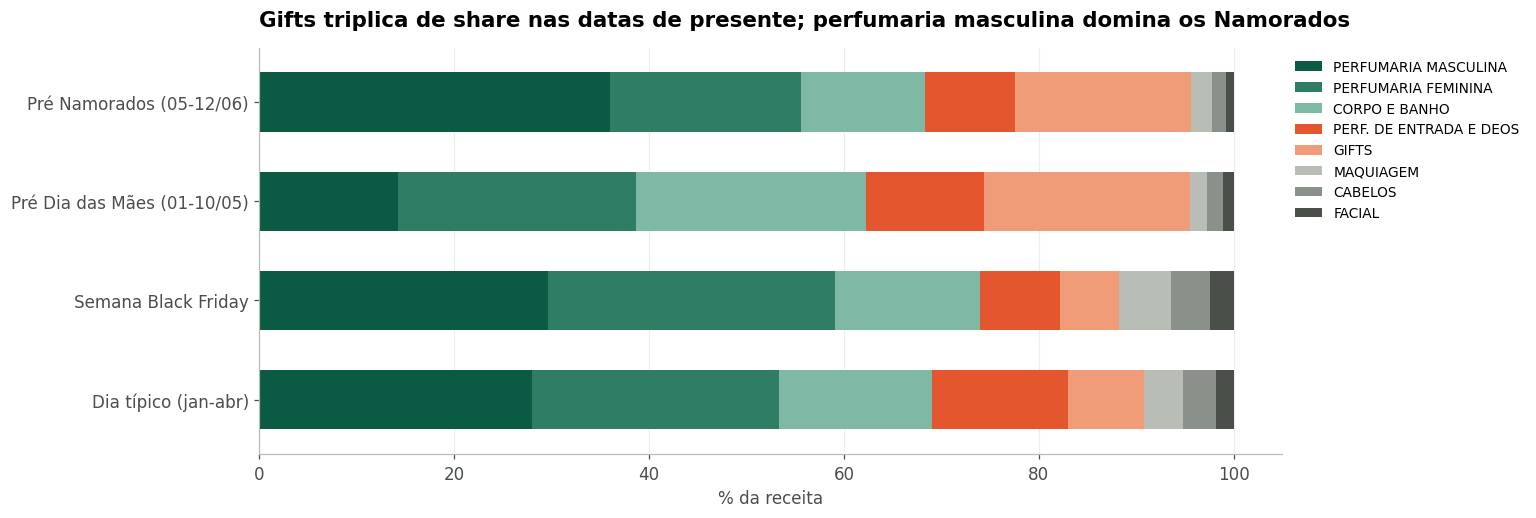

,Dia típico (jan-abr),Semana Black Friday,Pré Dia das Mães (01-10/05),Pré Namorados (05-12/06)
categoria,,,,
PERFUMARIA MASCULINA,27.90,29.70,14.20,36.00
PERFUMARIA FEMININA,25.40,29.40,24.40,19.50
CORPO E BANHO,15.70,14.90,23.50,12.80
PERF. DE ENTRADA E DEOS,14.00,8.20,12.10,9.20
GIFTS,7.80,6.10,21.10,18.10
MAQUIAGEM,4.00,5.30,1.80,2.10
CABELOS,3.40,4.00,1.60,1.50
FACIAL,1.80,2.40,1.10,0.80


In [16]:
def mix(a, b):
    s = k[(k.data >= a) & (k.data <= b)].groupby("categoria").receita_aprovada.sum(); return s / s.sum() * 100
mx = pd.DataFrame({"Dia típico (jan-abr)": mix("2026-01-05", "2026-04-25"),
                   "Semana Black Friday": mix("2025-11-24", "2025-11-30"),
                   "Pré Dia das Mães (01-10/05)": mix("2026-05-01", "2026-05-10"),
                   "Pré Namorados (05-12/06)": mix("2026-06-05", "2026-06-12")})
mx = mx.sort_values("Dia típico (jan-abr)", ascending=False)
fig, ax = plt.subplots(figsize=(12, 4.8))
mx.T.plot(kind="barh", stacked=True, ax=ax, color=sns.color_palette([VERDE, "#2E7D64", VERDE_CLARO, CORAL, "#F19C79", CINZA, "#8A918A", CINZA_ESC]), width=0.6)
ax.legend(bbox_to_anchor=(1, 1), loc="upper left", fontsize=9); ax.set_xlabel("% da receita"); ax.grid(axis="y", visible=False)
ax.set_title("Gifts triplica de share nas datas de presente; perfumaria masculina domina os Namorados")
salvar(fig, "02_mix_ocasiao"); plt.show()
mx.round(1)

**E daí:** em datas de presente, Gifts vai de 8% para 21% da receita (Dia das Mães) e 18% (Namorados), e Corpo e Banho sobe para 24% no Dia das Mães. Planejamento de estoque e vitrine do site deve mudar de mix, não só de volume, nessas semanas.

### 4.2 O App segue ganhando espaço

/tmp/ipykernel_584/4092950955.py:2: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  share = ch.App / ch.sum(1) * 100


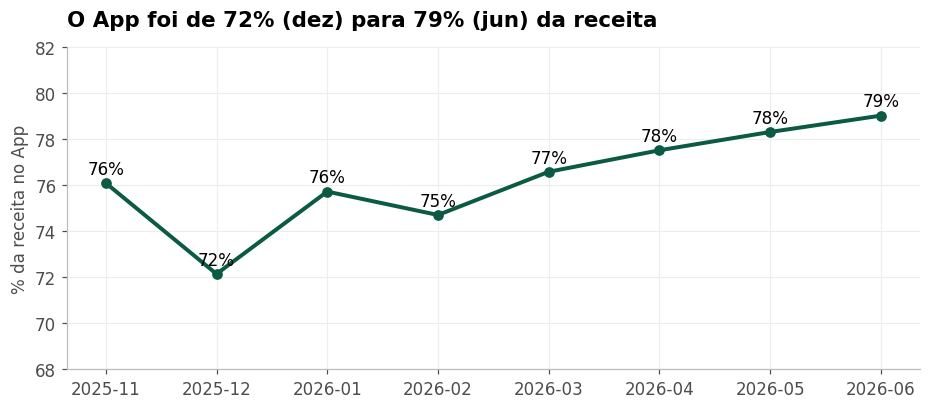

In [17]:
ch = df.groupby([df.dt_hr_venda.dt.to_period("M"), "canal"]).receita_aprovada.sum().unstack()
share = ch.App / ch.sum(1) * 100
fig, ax = plt.subplots(figsize=(10, 3.8))
ax.plot(share.index.astype(str), share.values, color=VERDE, lw=2.6, marker="o")
for i, v in enumerate(share.values): ax.text(i, v+0.4, f"{v:.0f}%", ha="center")
ax.set_ylim(68, 82); ax.set_ylabel("% da receita no App")
ax.set_title("O App foi de 72% (dez) para 79% (jun) da receita")
salvar(fig, "02_share_app"); plt.show()

### 4.3 A ressaca depois do pico

In [18]:
jan = pd.DataFrame({"Namorados": d.loc["2026-06-08":"2026-06-16", "receita_aprovada"].values,
                    "Dia das Mães": d.loc["2026-05-06":"2026-05-14", "receita_aprovada"].values},
                   index=[f"D{i}" for i in range(-4, 5)])
(jan/1e6).round(2).T

,D-4,D-3,D-2,D-1,D0,D1,D2,D3,D4
Namorados,2.57,2.69,2.33,2.71,3.00,0.98,0.79,1.45,1.64
Dia das Mães,3.50,3.86,4.72,4.58,2.04,1.52,1.60,1.74,1.64


**E daí:** a venda sobe na semana anterior à data e o pico acontece antes dela (Dia das Mães: sexta, 2 dias antes) ou no próprio dia (Namorados). Logo depois, a venda despenca: dois dias após os Namorados, a receita caiu para R$ 0,8 mi, menos da metade de um dia típico. Para o forecast, a variável certa não é "é o dia do evento", e sim "quantos dias faltam para o evento".

## 5. Resumo dos insights

| # | Insight | Recomendação |
|---|---|---|
| 1 | Novembro = 26% da receita de 8 meses, com preço 37% menor e desconto de 53% | Avaliar campanhas por margem, não só por receita |
| 2 | Black Friday é demanda comprada; Dia das Mães é orgânica (preço acima do normal, desconto 29%) | Desconto mais conservador em datas de presente |
| 3 | Sexta +10%, domingo -22% (sem eventos) | Disparos na quinta; testes de criativo no domingo |
| 4 | Dois picos (10h-14h e 20h-21h); App mais forte à noite, Site no horário comercial | E-mail e Site de manhã, push às 19h30; prever o fechamento do dia ao meio-dia |
| 5 | Gifts triplica nas datas de presente | Ajustar mix de estoque e vitrine, não só volume |
| 6 | App de 72% para 79% da receita | Priorizar experiência e CRM no App |
| 7 | Venda sobe na semana anterior à data e despenca logo depois | Modelar "dias até o evento" no forecast |